In [2]:
from matplotlib import pyplot as plt
import seaborn as sns
import platform

# OS에 맞춰 한글 폰트 자동 설정
if platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
# 마이너스기호 깨짐 방지
plt.rc('axes', unicode_minus=False)
# Seaborn 기본 스타일설정
sns.set_theme(style="whitegrid", font="AppleGothic" if platform.system() == 'Darwin' else "Malgun Gothic")

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [4]:
df = pd.read_csv("Oworld.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

target = "visitors"

feature_cols = [c for c in df.columns if c not in ["date", "weekend", target]]

X = df[feature_cols]
y = df[target]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0, random_state=42, max_iter=10000),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=500, max_depth=None, random_state=42, n_jobs=-1
    ),
    "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=50),
    "XGBoost": XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, max_depth=-1, learning_rate=0.01,
        random_state=42, verbosity=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500, depth=10, learning_rate=0.01,
        random_state=42, verbose=0
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

results = []
predictions = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(results_df)

                Model         RMSE          MAE        R2
0            CatBoost  1313.257573   806.589909  0.673038
1       Random Forest  1342.781801   830.716664  0.658171
2             XGBoost  1351.365606   845.240417  0.653787
3            LightGBM  1354.981493   858.599132  0.651932
4   Gradient Boosting  1381.077294   852.444057  0.638395
5       Decision Tree  1567.735505   900.211152  0.534046
6   Linear Regression  1675.988547  1194.206683  0.467475
7    Lasso Regression  1676.420103  1193.908774  0.467201
8    Ridge Regression  1676.816200  1194.164751  0.466949
9          ElasticNet  2104.289783  1570.797065  0.160523
10                SVR  2479.165335  1485.222893 -0.165223


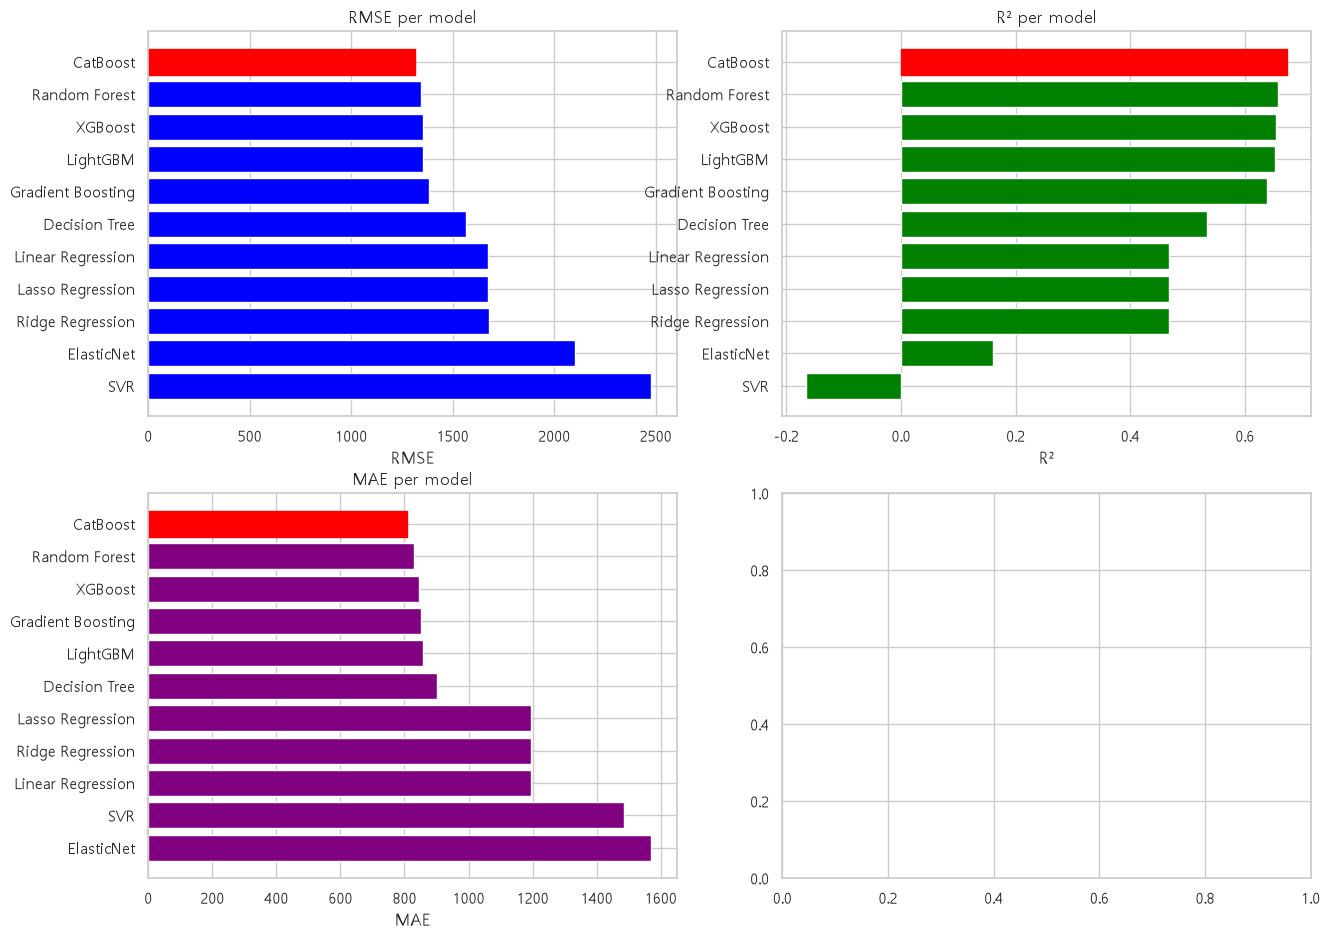

In [5]:
results_df = results_df.sort_values("RMSE")
 
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
 
# (1) RMSE 비교
ax = axes[0, 0]
bars = ax.barh(results_df["Model"], results_df["RMSE"], color="blue")
bars[0].set_color("red")
ax.set_xlabel("RMSE")
ax.set_title("RMSE per model")
ax.invert_yaxis()
 
# (2) R2 비교
ax = axes[0, 1]
results_sorted_r2 = results_df.sort_values("R2", ascending=False)
bars = ax.barh(results_sorted_r2["Model"], results_sorted_r2["R2"], color="green")
bars[0].set_color("red")
ax.set_xlabel("R²")
ax.set_title("R² per model")
ax.invert_yaxis()
 
# (3) MAE 비교
ax = axes[1, 0]
results_sorted_mae = results_df.sort_values("MAE")
bars = ax.barh(results_sorted_mae["Model"], results_sorted_mae["MAE"], color="purple")
bars[0].set_color("red")
ax.set_xlabel("MAE")
ax.set_title("MAE per model")
ax.invert_yaxis()

  MAE : 828.3 visitors
  RMSE: 1,310.2 visitors
  R2  : 0.675


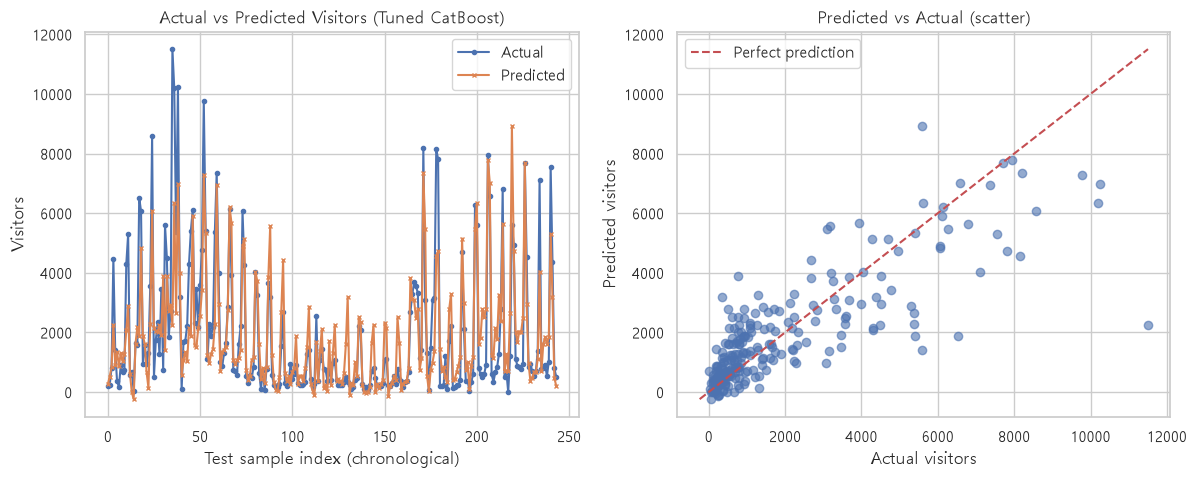

In [ ]:
df = pd.read_csv("Oworld.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

target = "visitors"

feature_cols = [c for c in df.columns if c not in ["date", "weekend", target]]

X = df[feature_cols]
y = df[target]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model = CatBoostRegressor(
        iterations=600, depth=4, learning_rate=0.02,
        random_state=42, verbose=0)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
 
print(f"  MAE : {mae:,.1f} visitors")
print(f"  RMSE: {rmse:,.1f} visitors")
print(f"  R2  : {r2:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(y_test.values, label="Actual", marker="o", markersize=3)
axes[0].plot(y_pred, label="Predicted", marker="x", markersize=3)
axes[0].set_title("Actual vs Predicted Visitors (Tuned CatBoost)")
axes[0].set_xlabel("Test sample index (chronological)")
axes[0].set_ylabel("Visitors")
axes[0].legend()
 
axes[1].scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, "r--", label="Perfect prediction")
axes[1].set_title("Predicted vs Actual (scatter)")
axes[1].set_xlabel("Actual visitors")
axes[1].set_ylabel("Predicted visitors")
axes[1].legend()
 
'''
example = pd.DataFrame([{
    "holiday": 0,
    "mon": 0, "tue": 0, "wed": 0, "thur": 1, "fri": 0, "sat": 0, "sun": 0,
    "temperature": 15.0,
    "rain": 0.1,
    "humidity": 55.0,
}])[feature_cols]
 
example_pred = model.predict(example)[0]
print(f"\nExample prediction for a hypothetical day: {example_pred:,.0f} visitors")
'''

# model.save_model("visitor_estimation_model.cbm")